# Hierarchical BH Mergers in Dense Star Clusters

Demonstrates `HierarchicalMergersInClusters` (Section III.C) from
Islam, Wadekar & Kritos (2026, arXiv:2603.10170).

In [1]:
import warnings
warnings.filterwarnings('ignore', 'Wswiglal-redir-stdio')

from gwGenealogy.core import HierarchicalMergersInClusters
from gwGenealogy.utils import set_rcparams
import matplotlib.pyplot as plt
import numpy as np

set_rcparams()

lal.MSUN_SI != Msun


## 2. Hierarchical Mergers Across Generations

Population-level simulation: 1G BHs merge pairwise to build 2G, 3G, etc.
Generation convention: `remnant_gen = max(parent_gen) + 1`.

In [2]:
sim = HierarchicalMergersInClusters(
    n_samples=5000000, chi_max=0.2, m_min=3, m_max=60, imf='uniform',
    pairing='random', kick_model='hlz', seed=42)
print(sim)
data = sim.simulate(verbose=True)

HierarchicalMergersInClusters(n=5000000, m=[3.0,60.0], IMF=uniform, chi_max=0.2, v_esc=uniform, pairing=random, kick=hlz)
1g: 5000000 BHs (m=[3.0,60.0] Msun, IMF=uniform, chi~U(0,0.2), v_esc~U(1.0,300.0))


2g: 3118216 BHs


/Users/tousifislam/Research/projects/stupid/refactor_gwModels/gwModels/gwModels/remnants/HBR_mass_spin.py:187: RuntimeWarning: invalid value encountered in sqrt
  chi_final = np.sqrt(term1 + term2 + term3) / (1.0 + small_q)**2


3g: 329747 BHs


4g: 71813 BHs
5g: 93564 BHs


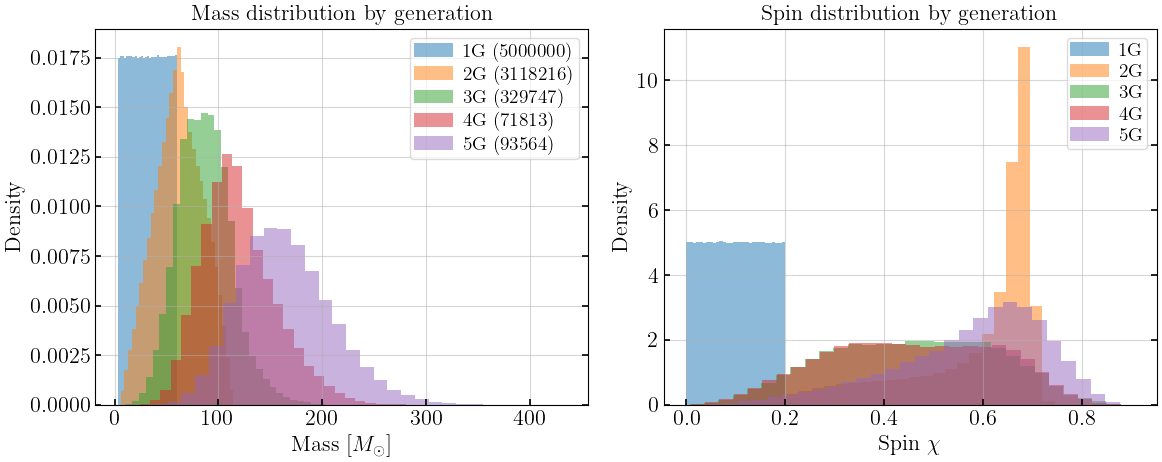

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['C0', 'C1', 'C2', 'C3', 'C4']

for g in range(1, sim.max_gen + 1):
    m = data[g]['m']
    s = data[g]['spin']
    if len(m) == 0:
        continue
    axes[0].hist(m, bins=30, alpha=0.5, color=colors[g-1], label=f'{g}G ({len(m)})', density=True)
    axes[1].hist(s, bins=30, alpha=0.5, color=colors[g-1], label=f'{g}G', density=True)

axes[0].set_xlabel('Mass [$M_\\odot$]')
axes[0].set_ylabel('Density')
axes[0].set_title('Mass distribution by generation')
axes[0].legend()

axes[1].set_xlabel('Spin $\\chi$')
axes[1].set_ylabel('Density')
axes[1].set_title('Spin distribution by generation')
axes[1].legend()

plt.tight_layout()
plt.show()

### Pairing model comparison

In [4]:
results = {}
for pairing in ['random', 'secondary_mass_power_law', 'total_mass_power_law']:
    sim_p = HierarchicalMergersInClusters(
        n_samples=50000, chi_max=0.2, pairing=pairing, kick_model='hlz', seed=42)
    results[pairing] = sim_p.simulate(verbose=False)
    counts = [len(results[pairing][g]['m']) for g in range(1, 6)]
    print(f"{pairing:30s}: {counts}")

random                        : [50000, 31787, 5221, 3676, 894]


secondary_mass_power_law      : [50000, 21820, 623, 281, 75]


total_mass_power_law          : [50000, 23975, 1595, 281, 153]


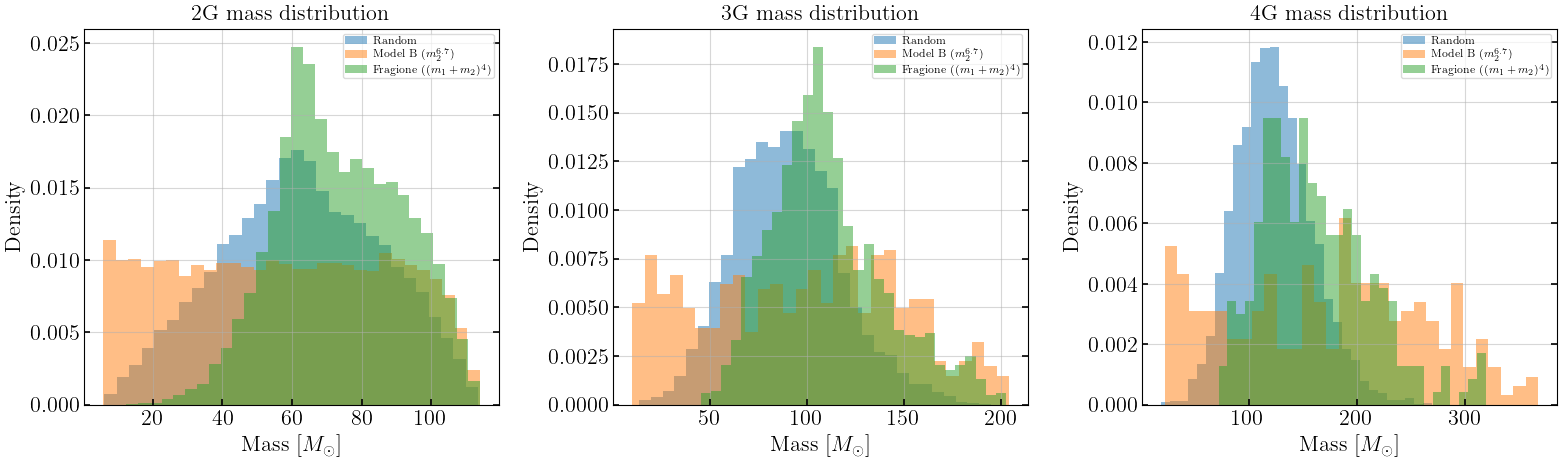

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = {'random': 'Random', 'secondary_mass_power_law': 'Model B ($m_2^{6.7}$)',
          'total_mass_power_law': 'Fragione ($(m_1+m_2)^4$)'}

for ax, g in zip(axes, [2, 3, 4]):
    for pairing, col in zip(results, ['C0', 'C1', 'C2']):
        m = results[pairing][g]['m']
        if len(m) > 0:
            ax.hist(m, bins=30, alpha=0.5, color=col, label=labels[pairing], density=True)
    ax.set_xlabel('Mass [$M_\\odot$]')
    ax.set_ylabel('Density')
    ax.set_title(f'{g}G mass distribution')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Evolving escape velocity

Clusters lose mass over time, so $v_{esc}$ decreases with generation.
With `evolve_v_esc=True`, sampled escape velocities are scaled as
$v_{esc}(g) = v_{esc,\mathrm{sampled}} \cdot g^{\alpha}$ where $\alpha = -0.35$
by default. Compare constant vs evolving $v_{esc}$.

In [6]:
n_seeds = 20
max_gen = 5
common_hier_kw = dict(n_samples=15000, chi_max=0.2, m_min=3, m_max=60,
                      imf='uniform', pairing='random', kick_model='hlz')

counts_const = np.zeros((n_seeds, max_gen))
counts_evolve = np.zeros((n_seeds, max_gen))

for s in range(n_seeds):
    d_c = HierarchicalMergersInClusters(
        evolve_v_esc=False, seed=s, **common_hier_kw).simulate()
    d_e = HierarchicalMergersInClusters(
        evolve_v_esc=True, seed=s, **common_hier_kw).simulate()
    for g in range(1, max_gen + 1):
        counts_const[s, g-1] = len(d_c[g]['m'])
        counts_evolve[s, g-1] = len(d_e[g]['m'])
    if (s + 1) % 5 == 0:
        print(f"  {s+1}/{n_seeds} seeds done")

mean_const = counts_const.mean(axis=0)
mean_evolve = counts_evolve.mean(axis=0)
std_const = counts_const.std(axis=0)
std_evolve = counts_evolve.std(axis=0)

print(f"\n{'Generation':>12s} {'constant':>12s} {'evolving':>12s} {'ratio':>8s}")
for g in range(max_gen):
    ratio = mean_evolve[g] / mean_const[g] if mean_const[g] > 0 else float('nan')
    print(f"{g+1:>10d}G {mean_const[g]:>8.0f}±{std_const[g]:<4.0f}"
          f"{mean_evolve[g]:>8.0f}±{std_evolve[g]:<4.0f} {ratio:>8.2f}")

  5/20 seeds done


/Users/tousifislam/Research/projects/stupid/refactor_gwModels/gwModels/gwModels/remnants/HBR_mass_spin.py:187: RuntimeWarning: invalid value encountered in sqrt
  chi_final = np.sqrt(term1 + term2 + term3) / (1.0 + small_q)**2


  10/20 seeds done


  15/20 seeds done


  20/20 seeds done

  Generation     constant     evolving    ratio
         1G    15000±0      15000±0        1.00
         2G     7304±1459    4971±1562     0.68
         3G     2193±1513     736±853      0.34
         4G      951±1116     246±350      0.26
         5G      828±1232      85±121      0.10


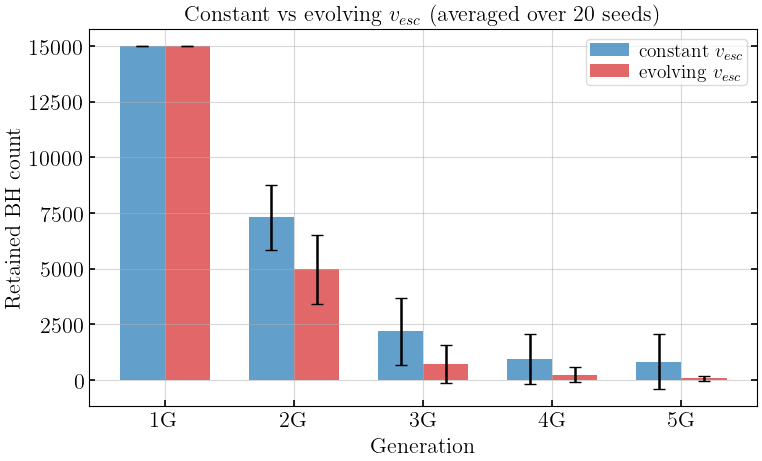

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
gens = np.arange(1, max_gen + 1)
x = np.arange(max_gen)
w = 0.35

ax.bar(x - w/2, mean_const, w, yerr=std_const, capsize=4,
       label='constant $v_{esc}$', color='C0', alpha=0.7)
ax.bar(x + w/2, mean_evolve, w, yerr=std_evolve, capsize=4,
       label='evolving $v_{esc}$', color='C3', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels([f'{g}G' for g in gens])
ax.set_xlabel('Generation')
ax.set_ylabel('Retained BH count')
ax.set_title(f'Constant vs evolving $v_{{esc}}$ (averaged over {n_seeds} seeds)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Paper-style generation plots

`plot_generations()` produces mass-spin scatter plots and mass histograms
by generation, matching the figure style from Islam, Wadekar & Kritos (2026).

- **Single model**: 2-panel (scatter + histogram)
- **Two-model comparison**: 3-panel (scatter each + overlaid histogram with bars vs step lines)

1g: 50000 BHs (m=[3.0,60.0] Msun, IMF=uniform, chi~U(0,0.2), v_esc~U(1.0,300.0))
2g: 28322 BHs
3g: 6497 BHs
4g: 1288 BHs
5g: 661 BHs


/Users/tousifislam/Research/projects/stupid/gwGenealogy/gwGenealogy/core/hierarchical.py:508: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


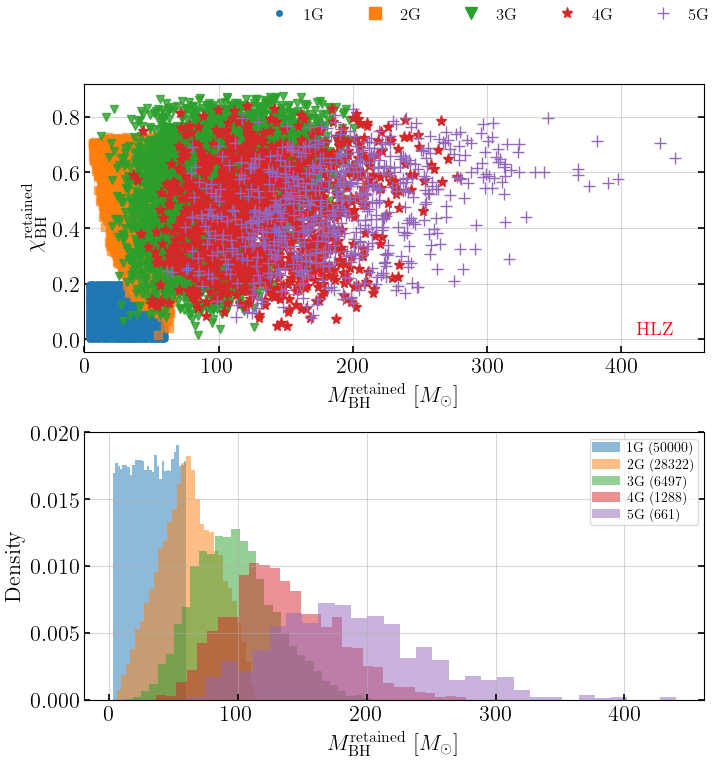

In [8]:
sim_hlz = HierarchicalMergersInClusters(
    n_samples=50000, chi_max=0.2, m_min=3, m_max=60, imf='uniform',
    pairing='random', kick_model='hlz', seed=42)
data_hlz = sim_hlz.simulate(verbose=True)

fig, axes = sim_hlz.plot_generations(data_hlz, label='HLZ')
plt.show()

### HLZ vs gwModel comparison (3-panel)

1g: 50000 BHs (m=[3.0,60.0] Msun, IMF=uniform, chi~U(0,0.2), v_esc~U(1.0,300.0))


2g: 28691 BHs


3g: 9940 BHs


4g: 4697 BHs


5g: 3125 BHs


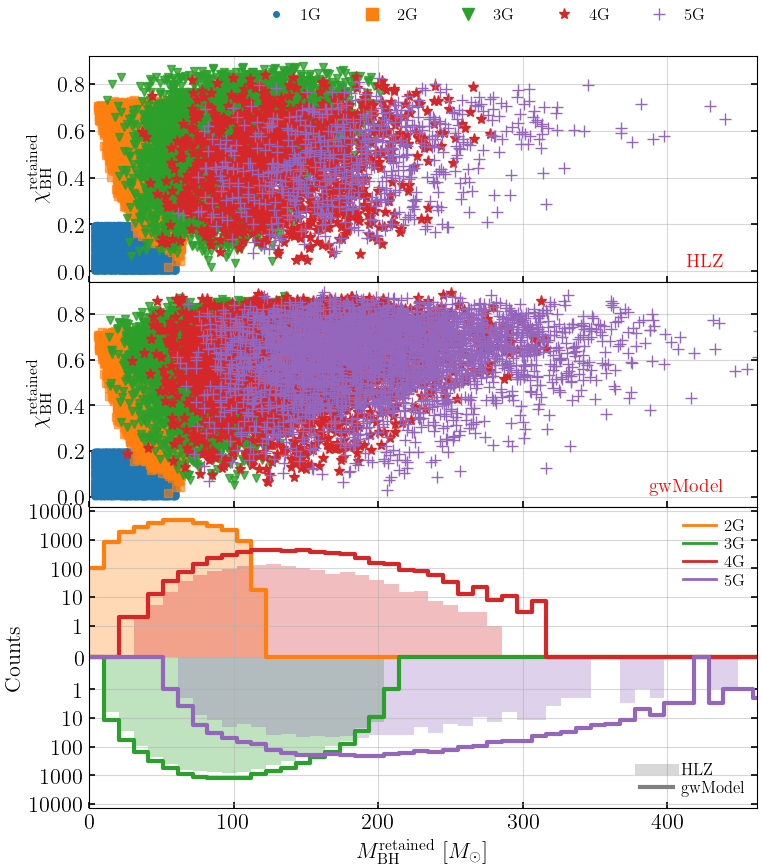

In [9]:
sim_gw = HierarchicalMergersInClusters(
    n_samples=50000, chi_max=0.2, m_min=3, m_max=60, imf='uniform',
    pairing='random', kick_model='gwmodel', seed=42)
data_gw = sim_gw.simulate(verbose=True)

fig, axes = sim_hlz.plot_generations(
    data_hlz, compare_data=data_gw,
    label='HLZ', compare_label='gwModel')
plt.show()